# Regresyon Genel

Bu notebookta 2. bölümde gördüğümüz tüm konuların üzerinden tekrardan geçecek ve bazı konularda ek bilgiler öğreneceğiz. O zaman hadi başlayalım :)

## 1. Veri Setini Yükleme ve Anlama

In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('train_market.csv')
test = pd.read_csv('test_market.csv')

In [3]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


> **SORU:** Train ve Test veri setlerinin içeriğini incelediğimizde bir şey dikkatimizi çekti mi?

## 2. Basit Linear Regresyon

In [7]:
from sklearn.model_selection import train_test_split

# X ve Y değişkenlerimizi oluşturma
X = train.loc[:,['Outlet_Establishment_Year','Item_MRP', 'Item_Visibility']]
y = train.Item_Outlet_Sales

# Train/Test Ayrımı
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train/Validation Ayrımı
x_train, x_cv, y_train, y_cv = train_test_split(X_train, Y_train, test_size=0.25, random_state=42)

In [8]:
print('X Train:', x_train.shape)
print('X Validation:', x_cv.shape)
print('X test:', x_test.shape)

X Train: (5113, 3)
X Validation: (1705, 3)
X test: (1705, 3)


In [9]:
from sklearn.linear_model import LinearRegression

# Modeli Oluşturma
lreg = LinearRegression()

lreg.fit(x_train,y_train)

pred = lreg.predict(x_cv)

# MSE Hesabı
mse = np.mean((pred - y_cv)**2)
print("MSE: ", mse)

# R2 Skor
print("R2 Score: ", lreg.score(x_cv, y_cv))

MSE:  1955437.3852380423
R2 Score:  0.32978638195070653


In [10]:
# Modelimizde yer alan katsayı değerleri
lreg.coef_

array([  -14.24033321,    15.78878622, -4457.75447671])

> **SORU:** Bu katsayı değerleri bizim için ne anlama geliyor? Hangi feature modelimize nasıl bir etki yapmış?

## 3. EDA & Feature Engineering

In [11]:
train['Item_Identifier'].value_counts()

FDW13    10
FDG33    10
FDD38     9
FDQ40     9
NCF42     9
         ..
FDY43     1
FDT35     1
FDK57     1
DRF48     1
FDE52     1
Name: Item_Identifier, Length: 1559, dtype: int64

> **SORU:** `Item_Identifier` sütunuyla ilgili ne düşünüyorsunuz?

In [12]:
train.loc[train['Item_Identifier'] == 'FDG33']

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
231,FDG33,NaN,Regular,0.139561,Seafood,170.4764,OUT027,1985,Medium,Tier 3,Supermarket Type3,3435.5280
1202,FDG33,5.365,Regular,0.140525,Seafood,172.7764,OUT045,2002,NaN,Tier 2,Supermarket Type1,2233.0932
1575,FDG33,NaN,Regular,0.245543,Seafood,172.2764,OUT019,1985,Small,Tier 1,Grocery Store,171.7764
2728,FDG33,5.365,Regular,0.234733,Seafood,173.4764,OUT010,1998,NaN,Tier 3,Grocery Store,171.7764
4747,FDG33,5.365,Regular,0.140458,Seafood,169.7764,OUT049,1999,Medium,Tier 1,Supermarket Type1,3263.7516
5164,FDG33,5.365,Regular,0.140240,Seafood,171.0764,OUT046,1997,Small,Tier 1,Supermarket Type1,3263.7516
6112,FDG33,5.365,Regular,0.141034,Seafood,173.6764,OUT017,2007,NaN,Tier 2,Supermarket Type1,858.8820
7011,FDG33,5.365,Regular,0.140812,Seafood,173.5764,OUT018,2009,Medium,Tier 3,Supermarket Type2,2061.3168
7098,FDG33,5.365,Regular,0.140124,Seafood,172.0764,OUT013,1987,High,Tier 3,Supermarket Type1,2748.4224
7726,FDG33,5.365,Regular,0.140214,Seafood,173.7764,OUT035,2004,Small,Tier 2,Supermarket Type1,4637.9628


- Aynı ürün birden fazla mağazada satılıyormuş olarak gözüküyor. Burada herhangi bir problem yok ancak yine de eğer veri setimizde tekrar eden kayıtlar var ise onları silmemiz lazım...

In [13]:
train.drop_duplicates(inplace=True) # (ÇOK ÖNEMLİ!)

In [14]:
train

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [15]:
test.drop_duplicates(inplace=True)

In [16]:
test

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3
...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1
5677,FDD47,7.600,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1


- Tekrar eden kaydımız yokmuş ancak biz yine de işi her zaman sağlama alalım :)

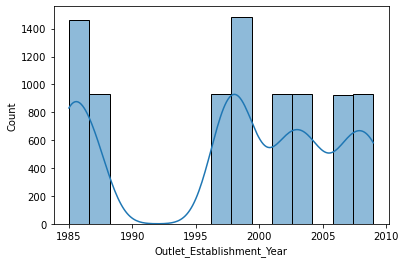

In [17]:
sns.histplot(data = train['Outlet_Establishment_Year'], kde=True);

In [18]:
train['Outlet_Establishment_Year'].describe()

count    8523.000000
mean     1997.831867
std         8.371760
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64

In [19]:
test['Outlet_Establishment_Year'].describe()

count    5681.000000
mean     1997.828903
std         8.372256
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64

In [20]:
train['Outlet_Establishment_Year'] = 2022 - train['Outlet_Establishment_Year']
test['Outlet_Establishment_Year'] = 2022 - test['Outlet_Establishment_Year']

> **SORU:** Böyle bir işleme neden ihtiyaç duymuş olabilirim?

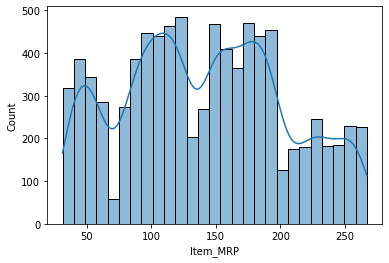

In [21]:
sns.histplot(data = train['Item_MRP'], kde=True);

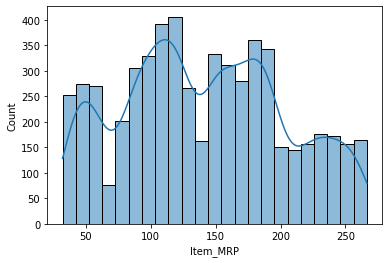

In [22]:
sns.histplot(data = test['Item_MRP'], kde=True);

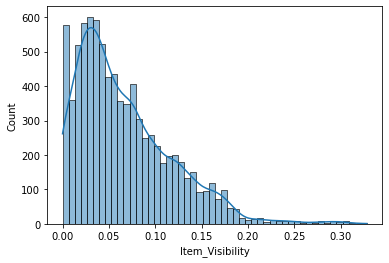

In [23]:
sns.histplot(data = train['Item_Visibility'], kde=True);

> **SORU:** Bu şekilde dağılım gösteren bir feature için ne yapmak lazım?

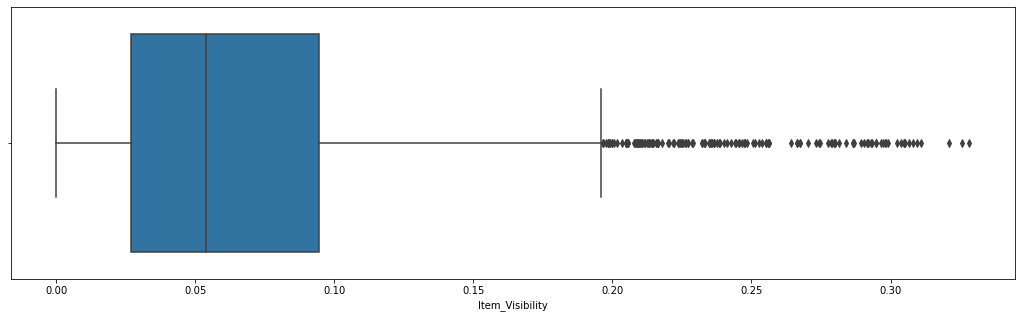

In [24]:
plt.figure(figsize=[18,5])
sns.boxplot(x=train['Item_Visibility'], data=train);

In [25]:
def extract_whiskers(data):
    median_value = np.median(data) # Medyan
    upper_quartile = np.percentile(data, 75) # 75%
    lower_quartile = np.percentile(data, 25) # 25% 

    iqr = upper_quartile - lower_quartile # Interquartile Range
    
    print("Upper Whisker:", data[data<=upper_quartile+1.5*iqr].max()) # Maksimum Kabul Edilen Değer
    print("Lower Whisker:", data[data>=lower_quartile-1.5*iqr].min()) # Minimum Kabul Edilen Değer

In [26]:
extract_whiskers(train['Item_Visibility'])

Upper Whisker: 0.195721125
Lower Whisker: 0.0


In [27]:
train = train.loc[train['Item_Visibility'] <= 0.195721125]
train

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,23,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,13,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,23,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,24,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,35,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,35,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,20,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,18,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,13,Medium,Tier 3,Supermarket Type2,1845.5976


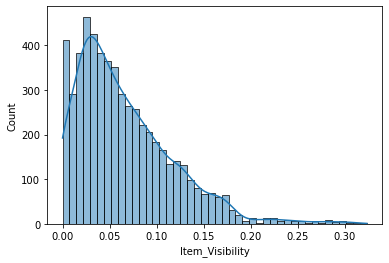

In [28]:
sns.histplot(data = test['Item_Visibility'], kde=True);

In [29]:
extract_whiskers(test['Item_Visibility'])

Upper Whisker: 0.192766917
Lower Whisker: 0.0


In [30]:
test = test.loc[test['Item_Visibility'] <= 0.192766917]
test

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,23,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,15,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,24,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,15,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,37,Medium,Tier 3,Supermarket Type3
...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500,Regular,0.013496,Snack Foods,141.3154,OUT046,25,Small,Tier 1,Supermarket Type1
5677,FDD47,7.600,Regular,0.142991,Starchy Foods,169.1448,OUT018,13,Medium,Tier 3,Supermarket Type2
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,20,NaN,Tier 2,Supermarket Type1
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,15,NaN,Tier 2,Supermarket Type1


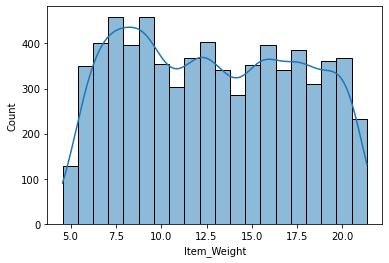

In [31]:
sns.histplot(data = train['Item_Weight'], kde=True);

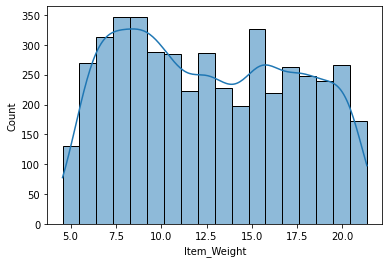

In [32]:
sns.histplot(data = test['Item_Weight'], kde=True);

> **HATIRLATMA!** `Item_Weight` sütunumuzda boş değerlerimiz vardı onları da unutmayalım :)

> **SORU:** O zaman `Item_Weight` sütunumuzda boş değerleri ne yapalım?

Daha önceki derslerimizde boş değerleri aritmetik ortalama, medyan ve mod gibi değerlerle doldurmanın çok temel stratejiler olduğunu konuşmuştuk. Bu onların kullanılamaz oldukları anlamına gelmiyor. Ancak bu tarz bir örnekte hiçbiri içimize tam olarak sinmiyor. Sanki başka bir yönteme ihtiyacımız varmış gibi. İşte karşımızda sayısal sütunlarımızdaki boş değerler için kullanabileceğimiz oldukça iyi bir istatiksel yaklaşım...

In [33]:
def mean_std_filling(column_name):    
    mean = column_name.mean()
    std = column_name.std()
    is_null = column_name.isna().sum()
    print('Mean:', mean, 'Std:', std, 'Null:', is_null)

    # Elimizdeki dizinin aritmetik ortalama ve standart sapma değerlerini kullanarak rastgele float veriler üretme
    rand_float = np.random.uniform(mean - std, mean + std, size = is_null)
    print('Numbers:', rand_float[:25])

    # Oluşturduğumuz sayılarla boş değerlerimizi doldurma
    column_name[np.isnan(column_name)] = rand_float
    column_name = column_name.astype(float)

In [34]:
mean_std_filling(train['Item_Weight'])

Mean: 12.86621121121121 Std: 4.6434460328436575 Null: 1386
Numbers: [15.12625613  8.9393993  13.57151115 11.37284661 15.31700274 17.22314844
  8.99705509 12.96012345 13.17474139 12.14777737 12.99052017 12.35427774
 11.2703439  16.14224217 13.58980372 11.47715965 14.48230578 10.12613207
  8.84336149 14.65854288 13.02225668 14.853063   10.27788352 16.96743527
 10.21324149]


In [35]:
train['Item_Weight'].isna().sum()

0

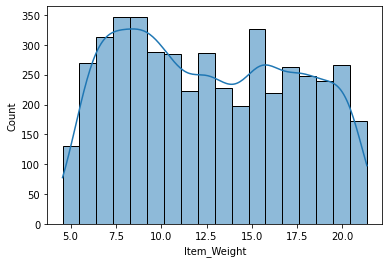

In [36]:
sns.histplot(data = test['Item_Weight'], kde=True);

In [37]:
mean_std_filling(test['Item_Weight'])

Mean: 12.697306368330466 Std: 4.666607468938025 Null: 920
Numbers: [14.31107813 14.52348154 10.09515922  9.91998918 14.68056235 11.07111524
 10.52260236 15.80013771 10.90919022 11.78219533 16.61979497 10.44039401
 16.24907588  8.65003334  8.55234447 10.55351641 10.96293134 13.32292033
  9.82639816  8.0771015  10.37831506 12.71542921 14.42710542  9.95887893
 14.38684558]


In [38]:
test['Item_Weight'].isna().sum()

0

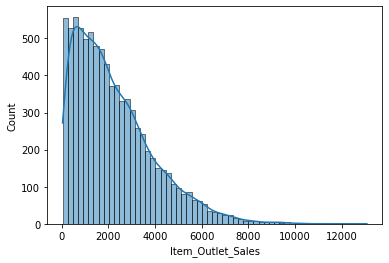

In [39]:
sns.histplot(data = train['Item_Outlet_Sales'], kde=True);

- Hmm, burada da hoşumuza gitmeyen bir durum var. Bazı ürünlerin satış fiyatları oldukça yüksekmiş. Bu durum modelimizi zorlayacak. Ama neyseki, biz bu tarz sorunların çözüm yöntemini öğrenmiştik :)

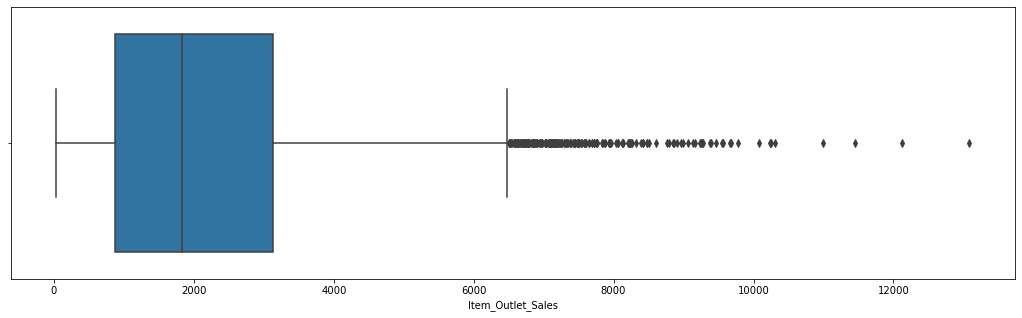

In [40]:
plt.figure(figsize=[18,5])
sns.boxplot(x=train['Item_Outlet_Sales'], data=train);

In [41]:
extract_whiskers(train['Item_Outlet_Sales'])

Upper Whisker: 6478.234
Lower Whisker: 33.29


In [42]:
train = train.loc[train['Item_Outlet_Sales'] <= 6478.234]
train

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,23,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,13,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,23,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,24,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,35,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,35,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,20,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,18,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,13,Medium,Tier 3,Supermarket Type2,1845.5976


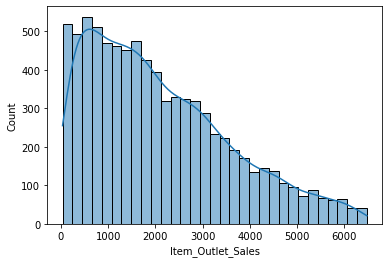

In [43]:
sns.histplot(data = train['Item_Outlet_Sales'], kde=True);

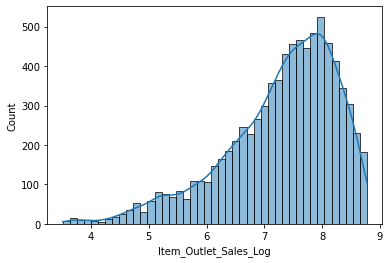

In [44]:
train['Item_Outlet_Sales_Log'] = np.log(train['Item_Outlet_Sales'])
sns.histplot(data = train['Item_Outlet_Sales_Log'], kde=True);

In [45]:
train['Item_Fat_Content'].value_counts()

Low Fat    4898
Regular    2769
LF          304
reg         115
low fat     107
Name: Item_Fat_Content, dtype: int64

- Burada durumlar biraz ilginç gibi duruyor :)

In [46]:
train['Item_Fat_Content'] = train['Item_Fat_Content'].apply(lambda x : x.replace("LF","Low Fat"))
train['Item_Fat_Content'] = train['Item_Fat_Content'].apply(lambda x : x.replace("low fat","Low Fat"))
train['Item_Fat_Content'] = train['Item_Fat_Content'].apply(lambda x : x.replace("reg","Regular"))

In [47]:
train['Item_Fat_Content'].value_counts()

Low Fat    5309
Regular    2884
Name: Item_Fat_Content, dtype: int64

In [48]:
train['Item_Type'].value_counts()

Fruits and Vegetables    1175
Snack Foods              1154
Household                 877
Frozen Foods              830
Dairy                     649
Canned                    626
Baking Goods              622
Health and Hygiene        507
Soft Drinks               428
Meat                      409
Breads                    242
Hard Drinks               207
Others                    167
Starchy Foods             139
Breakfast                 101
Seafood                    60
Name: Item_Type, dtype: int64

In [49]:
train['Outlet_Identifier'].value_counts()

OUT018    925
OUT046    920
OUT045    920
OUT049    919
OUT013    917
OUT035    914
OUT017    907
OUT027    832
OUT010    488
OUT019    451
Name: Outlet_Identifier, dtype: int64

In [50]:
train['Outlet_Size'].value_counts()

Medium    2676
Small     2285
High       917
Name: Outlet_Size, dtype: int64

> **HATIRLATMA!** `Outlet_Size` sütunumuzda da boş değerlerimiz vardı tabiki onları da unutmuyoruz :)

In [51]:
train['Outlet_Size'].isna().sum()

2315

> **SORU:** Peki bu **2343 tane** bilinmeyen değeri ne yapalım?

In [52]:
train['Outlet_Size'].fillna("Unknown", inplace=True)

In [53]:
train['Outlet_Size'].value_counts()

Medium     2676
Unknown    2315
Small      2285
High        917
Name: Outlet_Size, dtype: int64

In [54]:
train['Outlet_Location_Type'].value_counts()

Tier 3    3162
Tier 2    2741
Tier 1    2290
Name: Outlet_Location_Type, dtype: int64

In [55]:
train['Outlet_Type'].value_counts()

Supermarket Type1    5497
Grocery Store         939
Supermarket Type2     925
Supermarket Type3     832
Name: Outlet_Type, dtype: int64

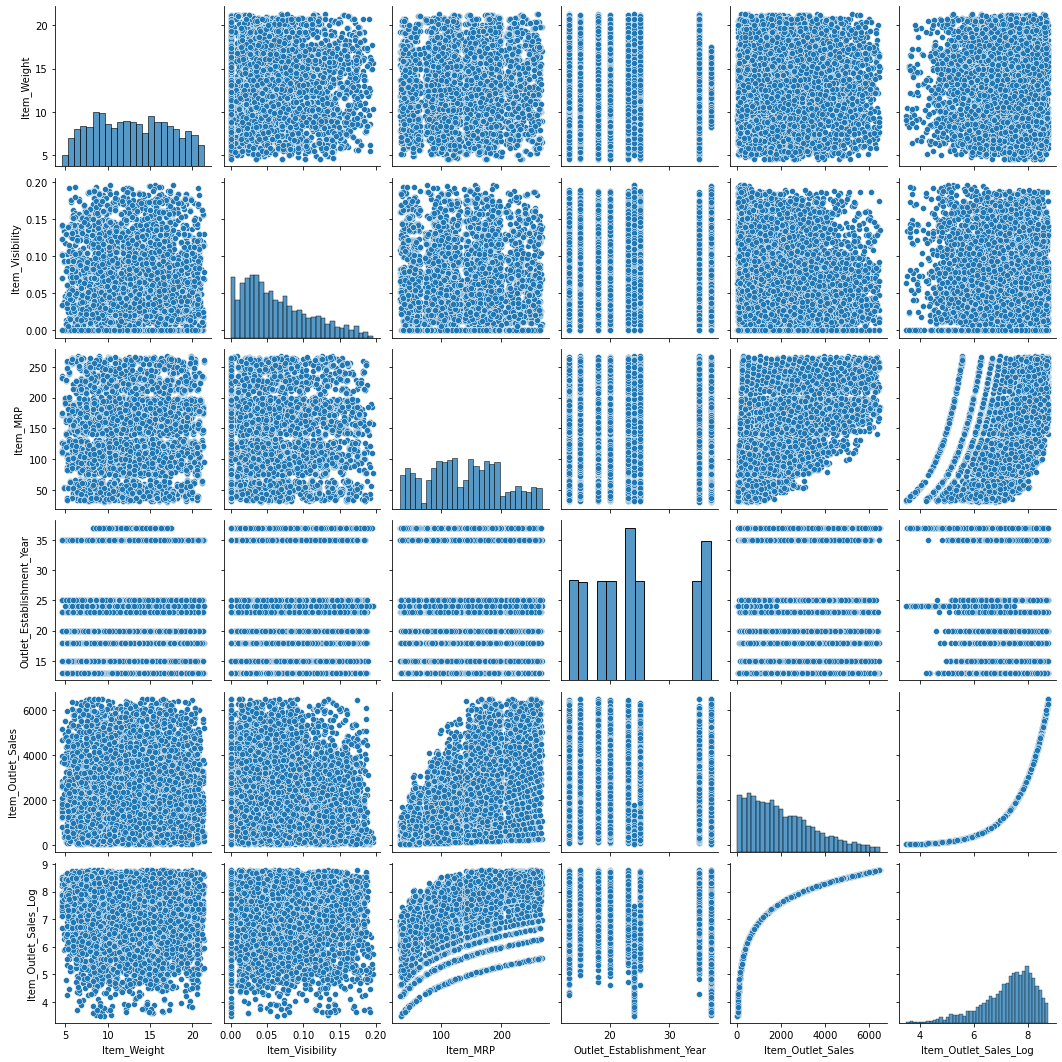

In [56]:
sns.pairplot(train);

In [57]:
train['Item_MRP_Log'] = np.log(train['Item_MRP'])

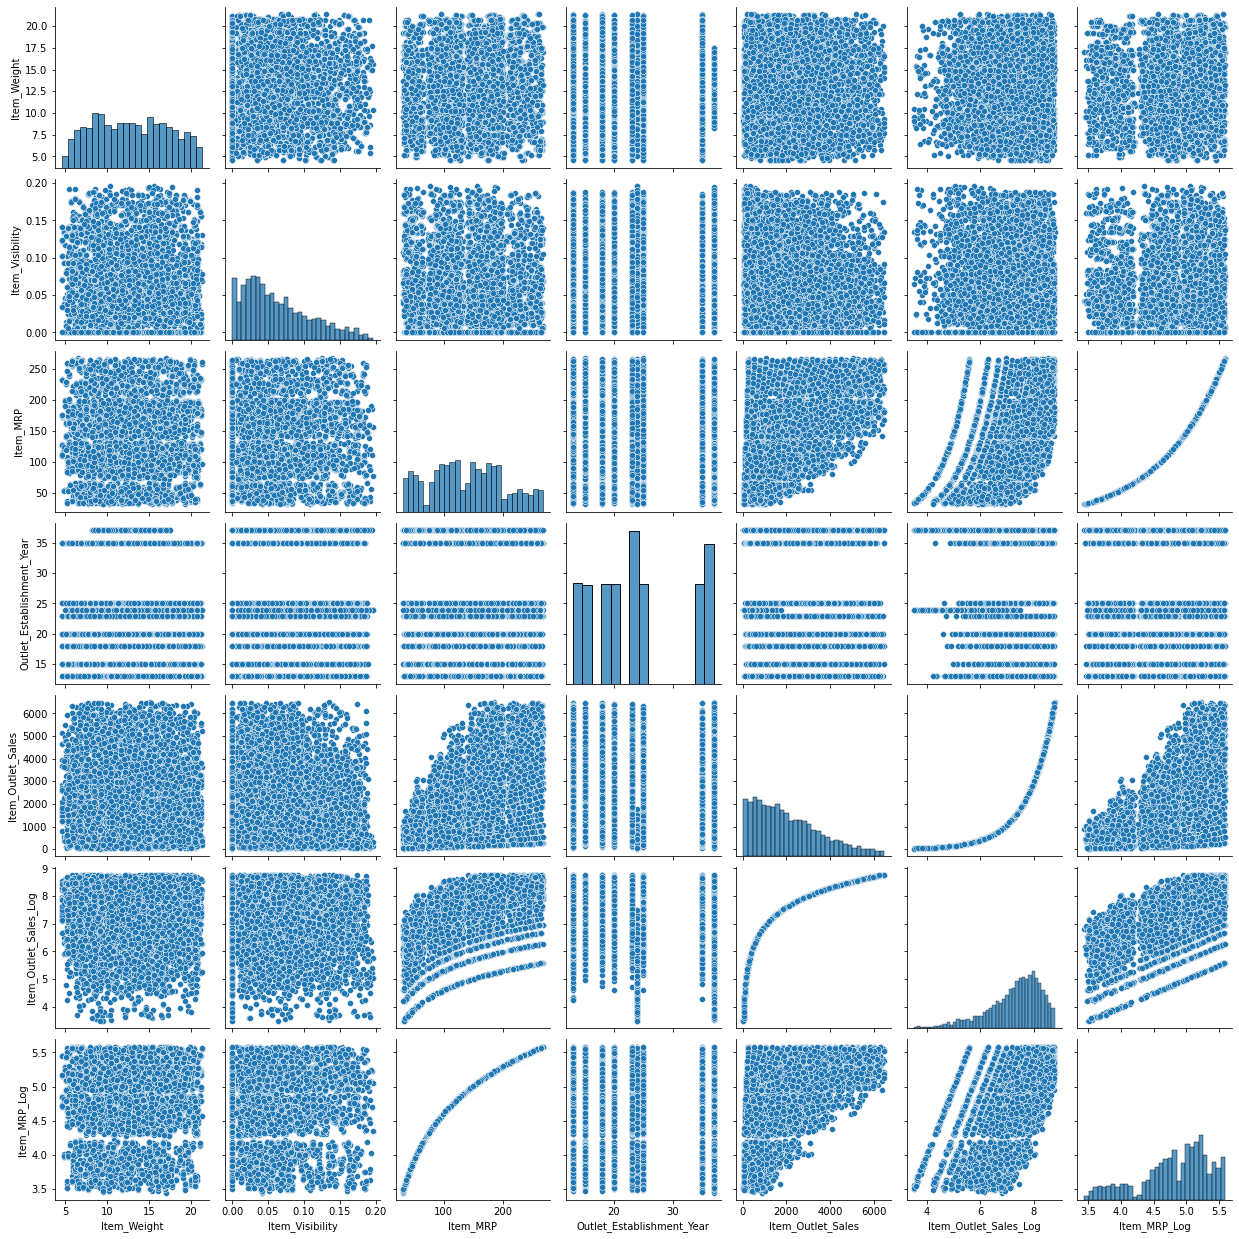

In [58]:
sns.pairplot(train);

In [59]:
train = pd.get_dummies(train, columns=['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
                                      'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'], drop_first=True)
train

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Outlet_Sales_Log,Item_MRP_Log,Item_Fat_Content_Regular,Item_Type_Breads,...,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Size_Unknown,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,FDA15,9.300,0.016047,249.8092,23,3735.1380,8.225540,5.520697,0,0,...,0,1,1,0,0,0,0,1,0,0
1,DRC01,5.920,0.019278,48.2692,13,443.4228,6.094524,3.876794,1,0,...,0,0,1,0,0,0,1,0,1,0
2,FDN15,17.500,0.016760,141.6180,23,2097.2700,7.648392,4.953133,0,0,...,0,1,1,0,0,0,0,1,0,0
3,FDX07,19.200,0.000000,182.0950,24,732.3800,6.596300,5.204529,1,0,...,0,0,0,0,1,0,1,0,0,0
4,NCD19,8.930,0.000000,53.8614,35,994.7052,6.902446,3.986414,0,0,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,0.056783,214.5218,35,2778.3834,7.929625,5.368411,0,0,...,0,0,0,0,0,0,1,1,0,0
8519,FDS36,8.380,0.046982,108.1570,20,549.2850,6.308617,4.683584,1,0,...,0,0,0,0,1,1,0,1,0,0
8520,NCJ29,10.600,0.035186,85.1224,18,1193.1136,7.084322,4.444090,0,0,...,0,0,0,1,0,1,0,1,0,0
8521,FDN46,7.210,0.145221,103.1332,13,1845.5976,7.520558,4.636021,1,0,...,0,0,1,0,0,0,1,0,1,0


- Aslında `Item_Identifier` sütunundaki bazı bilgiler de bizim için önemli olabilir. Ama bu sütuna `get_dummies()` yöntemini uyguladığımda, bu durum oldukça fazla sütunla karşılaşmamıza sebep olacak. İlk aşamada modelimizi bu feature'ı dahil etmeden kuralım ve sonuçlarına bakalım. Eğer tatmin olmazsak bu aşamaya tekrardan geri döneriz. Oldukça fazla sütunu olan veri setlerini de neden sevmediğimizi umarım hatırlıyorsunuzdur :)

In [60]:
train.drop(columns='Item_Identifier', inplace=True)
train

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Outlet_Sales_Log,Item_MRP_Log,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,...,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Size_Unknown,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0.016047,249.8092,23,3735.1380,8.225540,5.520697,0,0,0,...,0,1,1,0,0,0,0,1,0,0
1,5.920,0.019278,48.2692,13,443.4228,6.094524,3.876794,1,0,0,...,0,0,1,0,0,0,1,0,1,0
2,17.500,0.016760,141.6180,23,2097.2700,7.648392,4.953133,0,0,0,...,0,1,1,0,0,0,0,1,0,0
3,19.200,0.000000,182.0950,24,732.3800,6.596300,5.204529,1,0,0,...,0,0,0,0,1,0,1,0,0,0
4,8.930,0.000000,53.8614,35,994.7052,6.902446,3.986414,0,0,0,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0.056783,214.5218,35,2778.3834,7.929625,5.368411,0,0,0,...,0,0,0,0,0,0,1,1,0,0
8519,8.380,0.046982,108.1570,20,549.2850,6.308617,4.683584,1,0,0,...,0,0,0,0,1,1,0,1,0,0
8520,10.600,0.035186,85.1224,18,1193.1136,7.084322,4.444090,0,0,0,...,0,0,0,1,0,1,0,1,0,0
8521,7.210,0.145221,103.1332,13,1845.5976,7.520558,4.636021,1,0,0,...,0,0,1,0,0,0,1,0,1,0


In [61]:
test['Item_Fat_Content'].value_counts()

Low Fat    3339
Regular    1890
LF          200
reg          74
low fat      65
Name: Item_Fat_Content, dtype: int64

In [62]:
test['Item_Fat_Content'] = test['Item_Fat_Content'].apply(lambda x : x.replace("LF","Low Fat"))
test['Item_Fat_Content'] = test['Item_Fat_Content'].apply(lambda x : x.replace("low fat","Low Fat"))
test['Item_Fat_Content'] = test['Item_Fat_Content'].apply(lambda x : x.replace("reg","Regular"))

In [63]:
test['Item_Fat_Content'].value_counts()

Low Fat    3604
Regular    1964
Name: Item_Fat_Content, dtype: int64

In [64]:
test['Item_Type'].value_counts()

Snack Foods              768
Fruits and Vegetables    765
Household                631
Frozen Foods             549
Dairy                    446
Baking Goods             433
Canned                   423
Health and Hygiene       333
Meat                     308
Soft Drinks              278
Breads                   160
Hard Drinks              145
Starchy Foods            119
Others                   110
Breakfast                 75
Seafood                   25
Name: Item_Type, dtype: int64

In [65]:
test['Outlet_Identifier'].value_counts()

OUT027    624
OUT013    621
OUT046    620
OUT035    620
OUT049    620
OUT045    619
OUT018    618
OUT017    617
OUT010    313
OUT019    296
Name: Outlet_Identifier, dtype: int64

In [66]:
test['Outlet_Size'].value_counts() 

Medium    1862
Small     1536
High       621
Name: Outlet_Size, dtype: int64

In [67]:
test['Outlet_Size'].isna().sum()

1549

In [68]:
test['Outlet_Size'].fillna("Unknown", inplace=True)

In [69]:
test['Outlet_Size'].value_counts()

Medium     1862
Unknown    1549
Small      1536
High        621
Name: Outlet_Size, dtype: int64

In [70]:
test['Outlet_Location_Type'].value_counts()

Tier 3    2176
Tier 2    1856
Tier 1    1536
Name: Outlet_Location_Type, dtype: int64

In [71]:
test['Outlet_Type'].value_counts()

Supermarket Type1    3717
Supermarket Type3     624
Supermarket Type2     618
Grocery Store         609
Name: Outlet_Type, dtype: int64

In [72]:
test['Item_MRP_Log'] = np.log(test['Item_MRP'])

In [73]:
test = pd.get_dummies(test, columns=['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
                                     'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'], drop_first=True)
test

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_MRP_Log,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Size_Unknown,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,FDW58,20.750000,0.007565,107.8622,23,4.680854,0,0,0,0,...,0,1,1,0,0,0,0,1,0,0
1,FDW14,8.300000,0.038428,87.3198,15,4.469577,1,0,0,0,...,0,0,0,0,1,1,0,1,0,0
2,NCN55,14.600000,0.099575,241.7538,24,5.487920,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,FDQ58,7.315000,0.015388,155.0340,15,5.043644,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
4,FDY38,14.311078,0.118599,234.2300,37,5.456304,1,0,0,0,...,0,0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500000,0.013496,141.3154,25,4.950994,1,0,0,0,...,1,0,0,1,0,0,0,1,0,0
5677,FDD47,7.600000,0.142991,169.1448,13,5.130755,1,0,0,0,...,0,0,1,0,0,0,1,0,1,0
5678,NCO17,10.000000,0.073529,118.7440,20,4.776970,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
5679,FDJ26,15.300000,0.000000,214.6218,15,5.368877,1,0,0,1,...,0,0,0,0,1,1,0,1,0,0


In [74]:
test.drop(columns='Item_Identifier', inplace=True)
test

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_MRP_Log,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Size_Unknown,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,20.750000,0.007565,107.8622,23,4.680854,0,0,0,0,0,...,0,1,1,0,0,0,0,1,0,0
1,8.300000,0.038428,87.3198,15,4.469577,1,0,0,0,1,...,0,0,0,0,1,1,0,1,0,0
2,14.600000,0.099575,241.7538,24,5.487920,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,7.315000,0.015388,155.0340,15,5.043644,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
4,14.311078,0.118599,234.2300,37,5.456304,1,0,0,0,1,...,0,0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676,10.500000,0.013496,141.3154,25,4.950994,1,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
5677,7.600000,0.142991,169.1448,13,5.130755,1,0,0,0,0,...,0,0,1,0,0,0,1,0,1,0
5678,10.000000,0.073529,118.7440,20,4.776970,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
5679,15.300000,0.000000,214.6218,15,5.368877,1,0,0,1,0,...,0,0,0,0,1,1,0,1,0,0


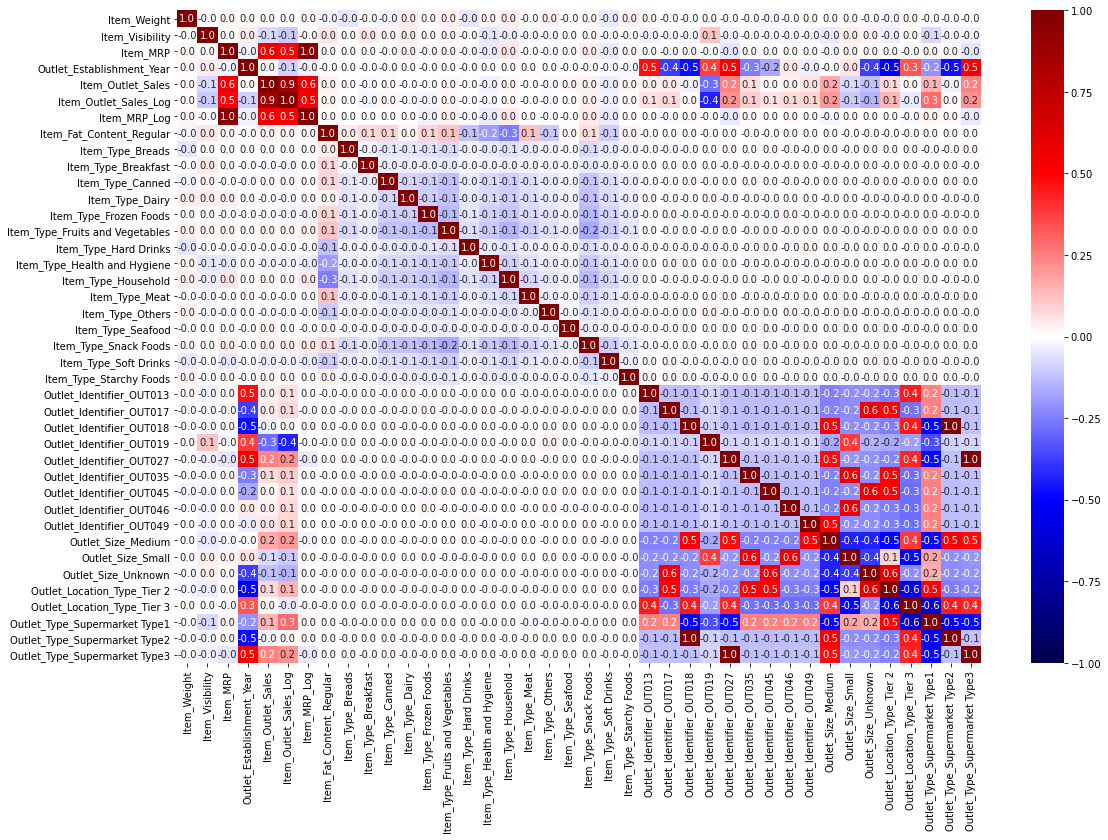

In [75]:
plt.figure(figsize=[18,12])
sns.heatmap(train.corr(), cmap="seismic", annot=True, vmin=-1, vmax=1, fmt='.1f');

## 4. Model Oluşturma

Veri setimizi hazırladığımıza göre en iyi modeli belirlemek için artık modellerimizi oluşturmaya başlayabiliriz. İlk olarak **Lineer Regresyon**'la başlayalım.

In [76]:
X = train.drop(columns=['Item_Outlet_Sales', 'Item_Outlet_Sales_Log'])
y = train.Item_Outlet_Sales_Log


X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_train, x_cv, y_train, y_cv = train_test_split(X_train, Y_train, test_size=0.25, random_state=42)

In [77]:
lreg = LinearRegression()

lreg.fit(x_train,y_train)

pred = lreg.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

# Hata Metrikleri
print("Validation Score: ", lreg.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  0.7114757060198352
MSE:  0.27759274399194606


In [78]:
X = train.drop(columns=['Item_Outlet_Sales', 'Item_Outlet_Sales_Log', 'Outlet_Identifier_OUT018', 'Outlet_Identifier_OUT027', 'Item_MRP'])
y = train.Item_Outlet_Sales_Log


X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_train, x_cv, y_train, y_cv = train_test_split(X_train, Y_train, test_size=0.25, random_state=42)

- İlk olarak **train veri setindeki** başarımıza bakalım.

In [79]:
lreg = LinearRegression()

lreg.fit(x_train,y_train)

pred = lreg.predict(x_train)

mse = np.mean((pred - y_train)**2)

# Hata Metrikleri
print("Validation Score: ", lreg.score(x_train, y_train))
print("MSE: ", mse)

Validation Score:  0.729396059450633
MSE:  0.26008082193024423


- İkinci olarak da **validation veri setindeki** başarı. Bu çok daha önemli!

In [80]:
lreg = LinearRegression()

lreg.fit(x_train,y_train)

pred = lreg.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

print("Validation Score: ", lreg.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  0.7111591016328924
MSE:  0.27789735293602813


> **SORU:** **Train** ve **Validation** veri setlerinde benzer sonuçlar aldık. Bu bizim için ne anlama geliyor?

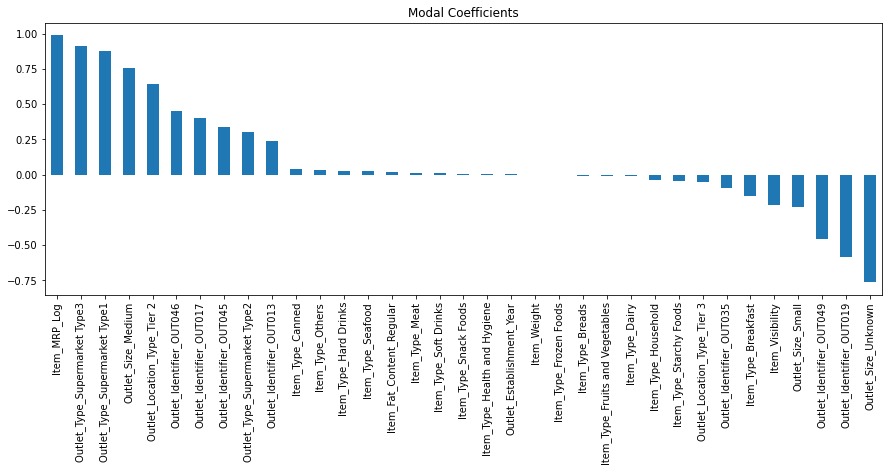

In [81]:
predictors = x_train.columns
coef = Series(lreg.coef_,predictors).sort_values(ascending=False)
plt.figure(figsize=[15,5])
coef.plot(kind='bar', title='Modal Coefficients');

- İlk aşamada öğrendiğimiz veri manipülasyonu yöntemlerini kullanarak Validation skorumuzu ancak **0.68** olarak bulabildik. Fena değil, ama tabiki iyi bir model olabilmesi için hala geliştirilmesi lazım. Hadi şimdi bir de Regularization yöntemlerimizi uygulayalım ve sonuca olan etkilerini gözlemleyelim. İlk olarak **Ridge**'i deneyelim.

In [82]:
from sklearn.linear_model import Ridge

ridgeReg = Ridge(alpha=1, normalize=True)

ridgeReg.fit(x_train,y_train)

pred = ridgeReg.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

print("Validation Score: ", ridgeReg.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  0.5029791345394186
MSE:  0.4781898396186341


- Oluşturduğumuz Ridge modelimiz, Validation skorumuzda ciddi bir düşüşe sebep oldu. Bir de **Regularization Katsayısı (alpha)** ile oynayalım ve elde ettiğimiz sonucu nasıl değiştirdiğini gözlemleyelim.

In [83]:
ridgeReg2 = Ridge(alpha=10, normalize=True)

ridgeReg2.fit(x_train,y_train)

pred = ridgeReg2.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

print("Validation Score: ", ridgeReg2.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  0.12193187023689667
MSE:  0.844800062380788


In [84]:
ridgeReg3 = Ridge(alpha=100, normalize=True)

ridgeReg3.fit(x_train,y_train)

pred = ridgeReg3.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

print("Validation Score: ", ridgeReg3.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  0.013221428156580561
MSE:  0.9493917052589681


- Ridge modelimizde Regularization katsayısını her arttığımızda model daha da kötüye gitti. Sanırım Ridge bizim sorunumuz için uygun bir çözüm gibi durmuyor. Şimdi de, bu konuda bir de **Lasso**'dan destek almayı deneyelim.

In [85]:
from sklearn.linear_model import Lasso

lassoReg = Lasso(alpha=1, normalize=True)

lassoReg.fit(x_train,y_train)

pred = lassoReg.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

print("Validation Score: ", lassoReg.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  -0.0011552630597220226
MSE:  0.9632236953115378


In [86]:
lassoReg2 = Lasso(alpha=10, normalize=True)

lassoReg2.fit(x_train,y_train)

pred = lassoReg2.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

print("Validation Score: ", lassoReg2.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  -0.0011552630597220226
MSE:  0.9632236953115378


In [87]:
lassoReg3 = Lasso(alpha=100, normalize=True)

lassoReg3.fit(x_train,y_train)

pred = lassoReg3.predict(x_cv)

mse = np.mean((pred - y_cv)**2)

print("Validation Score: ", lassoReg3.score(x_cv, y_cv))
print("MSE: ", mse)

Validation Score:  -0.0011552630597220226
MSE:  0.9632236953115378


- Maalesef Lasso'da istediğimiz sonucu vermedi. Bir türlü model skorumuzu daha da arttırmayı başaramadık :( İstediğimiz seviyelere ulaşamasak da yine de elimizde çok kötü bir model yok. Şimdi de, modelimizin gerçek performansını modelin testi için ayırdığımız veri setinde görelim.

In [88]:
lreg = LinearRegression()

lreg.fit(X_train,Y_train)

pred = lreg.predict(x_test)

mse = np.mean((pred - y_test)**2)

print("Test Score: ", lreg.score(x_test, y_test))
print("MSE: ", mse)

Test Score:  0.7154309753826431
MSE:  0.2631348644893138


- Çok benzer bir sonucu test için ayırdığımız veri setimizde de ulaştık. Bu iyi bir şey, modelimizde bir **Overfitting** sorunu olmadığı hakkında üstte bulduğumuz sonucu destekliyor. Bitirmeden bir de test için olan veri setimizde tahminler yapmayı deneyelim.

In [89]:
test.drop(columns=['Outlet_Identifier_OUT018', 'Outlet_Identifier_OUT027', 'Item_MRP'], inplace=True)

In [90]:
lreg.predict(test)

array([7.37170104, 7.12785046, 6.18038744, ..., 7.41442343, 8.09254543,
       7.06248906])

- Bu değerler aslında modelimizin gerçekten tahmin ettiği değerler. Ama bir tuhaflık var değil mi, bu kadar küçük değildi bizim satış değerlerimiz? Doğru, çünkü satış değerlerimize `np.log()` fonksiyonu uygulamıştık. Hadi şimdi tahminlerimizi orjinal haline geri döndürelim.

In [91]:
np.exp(lreg.predict(test))

array([1590.3367062 , 1246.19533447,  483.17912256, ..., 1659.75193485,
       3270.00053289, 1167.34715023])

In [92]:
test['Prediction'] = np.exp(lreg.predict(test))
test

,Item_Weight,Item_Visibility,Outlet_Establishment_Year,Item_MRP_Log,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,...,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Size_Unknown,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Prediction
0,20.750000,0.007565,23,4.680854,0,0,0,0,0,0,...,1,1,0,0,0,0,1,0,0,1590.336706
1,8.300000,0.038428,15,4.469577,1,0,0,0,1,0,...,0,0,0,1,1,0,1,0,0,1246.195334
2,14.600000,0.099575,24,5.487920,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,483.179123
3,7.315000,0.015388,15,5.043644,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,0,2235.746890
4,14.311078,0.118599,37,5.456304,1,0,0,0,1,0,...,0,1,0,0,0,1,0,0,1,5328.343571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676,10.500000,0.013496,25,4.950994,1,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,2034.220492
5677,7.600000,0.142991,13,5.130755,1,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,2071.939756
5678,10.000000,0.073529,20,4.776970,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,0,1659.751935
5679,15.300000,0.000000,15,5.368877,1,0,0,1,0,0,...,0,0,0,1,1,0,1,0,0,3270.000533


> **SORU:** Yapabileceğimiz işlemler buraya kadar mıydı? Modelimizi daha da geliştirmek için başka neler yapabilirdik?